In [12]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import warnings
import sqlite3
from scipy.stats import ttest_ind
import scipy.stats as stats
warnings.filterwarnings('ignore')

In [13]:
#Loading the dataset
conn = sqlite3.connect('inventory.db')

#fetching vendor summary data 
df=pd.read_sql_query("select * from vendor_sales_summary",conn)
df.head()

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalesToPurchaseRatio
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,145080,3811251.60,142049.0,5101919.51,672819.31,260999.20,68601.68,1290667.91,25.30,0.979108,1.338647
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,164038,3804041.22,160247.0,4819073.49,561512.37,294438.66,144929.24,1015032.27,21.06,0.976890,1.266830
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,187407,3418303.68,187140.0,4538120.60,461140.15,343854.07,123780.22,1119816.92,24.68,0.998575,1.327594
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,201682,3261197.94,200412.0,4475972.88,420050.01,368242.80,257032.07,1214774.94,27.14,0.993703,1.372493
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,138109,3023206.01,135838.0,4223107.62,545778.28,249587.83,257032.07,1199901.61,28.41,0.983556,1.396897


In [14]:
# summary statistics
df.describe().T

,count,mean,std,min,25%,50%,75%,max
VendorNumber,10692.0,1.065065e+04,18753.519148,2.00,3951.000000,7153.000000,9552.000000,2.013590e+05
Brand,10692.0,1.803923e+04,12662.187074,58.00,5793.500000,18761.500000,25514.250000,9.063100e+04
PurchasePrice,10692.0,2.438530e+01,109.269375,0.36,6.840000,10.455000,19.482500,5.681810e+03
ActualPrice,10692.0,3.564367e+01,148.246016,0.49,10.990000,15.990000,28.990000,7.499990e+03
Volume,10692.0,8.473605e+02,664.309212,50.00,750.000000,750.000000,750.000000,2.000000e+04
TotalPurchaseQuantity,10692.0,3.140887e+03,11095.086769,1.00,36.000000,262.000000,1975.750000,3.376600e+05
TotalPurchaseDollars,10692.0,3.010669e+04,123067.799627,0.71,453.457500,3655.465000,20738.245000,3.811252e+06
TotalSalesQuantity,10692.0,3.077482e+03,10952.851391,0.00,33.000000,261.000000,1929.250000,3.349390e+05
TotalSalesDollars,10692.0,4.223907e+04,167655.265984,0.00,729.220000,5298.045000,28396.915000,5.101920e+06
TotalSalesPrice,10692.0,1.879378e+04,44952.773386,0.00,289.710000,2857.800000,16059.562500,6.728193e+05


### Step 1: Select Features for Clustering

In [15]:
features = df[['GrossProfit', 'StockTurnover', 'FreightCost', 'ProfitMargin']]


### Step 2: Handle Missing and Infinite Values

In [16]:
import numpy as np

# Replace inf with NaN and drop
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna(subset=['GrossProfit', 'StockTurnover', 'FreightCost', 'ProfitMargin'])


###  Step 3: Standardize the Features

In [17]:
from sklearn.preprocessing import StandardScaler

X = df[['GrossProfit', 'StockTurnover', 'FreightCost', 'ProfitMargin']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


###  Step 4: Apply K-Means Clustering

In [18]:
from sklearn.cluster import KMeans

# Try 3 clusters to start with
kmeans = KMeans(n_clusters=3, random_state=42)
df['VendorCluster'] = kmeans.fit_predict(X_scaled)


### Step 5: Analyze the Clusters

In [19]:
# Cluster Summary
df.groupby('VendorCluster')[['GrossProfit', 'StockTurnover', 'FreightCost', 'ProfitMargin']].mean()


,GrossProfit,StockTurnover,FreightCost,ProfitMargin
VendorCluster,,,,
0,8559.012583,1.519032,33384.389654,-17.464015
1,14285.861761,2.490309,156847.580493,-11.524002
2,506985.494906,0.992935,120903.911321,29.656981


###  Step 6: Visualize the Clusters (Optional)

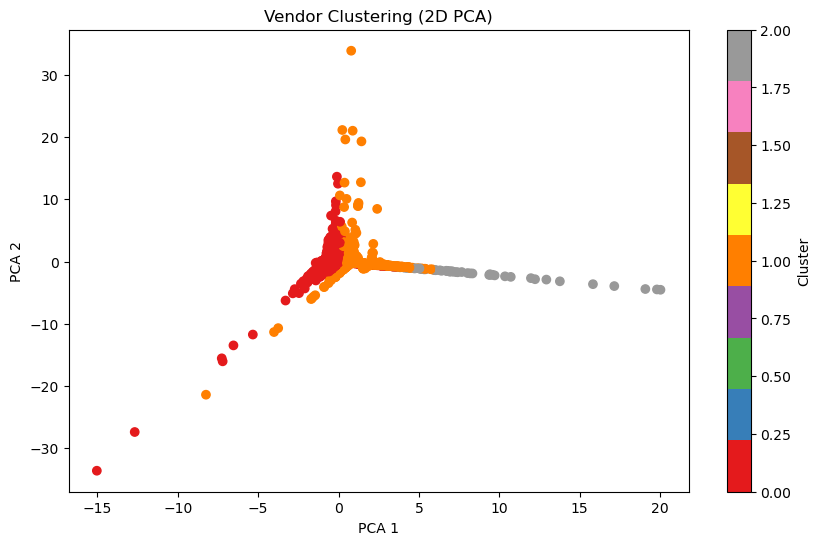

In [20]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df['VendorCluster'], cmap='Set1')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('Vendor Clustering (2D PCA)')
plt.colorbar(label='Cluster')
plt.show()


#### Each vendor labeled with a cluster number.

#### Summary of average metrics per cluster.

#### Option to target specific clusters for procurement strategies.

###  Elbow Method to Find Optimal Clusters

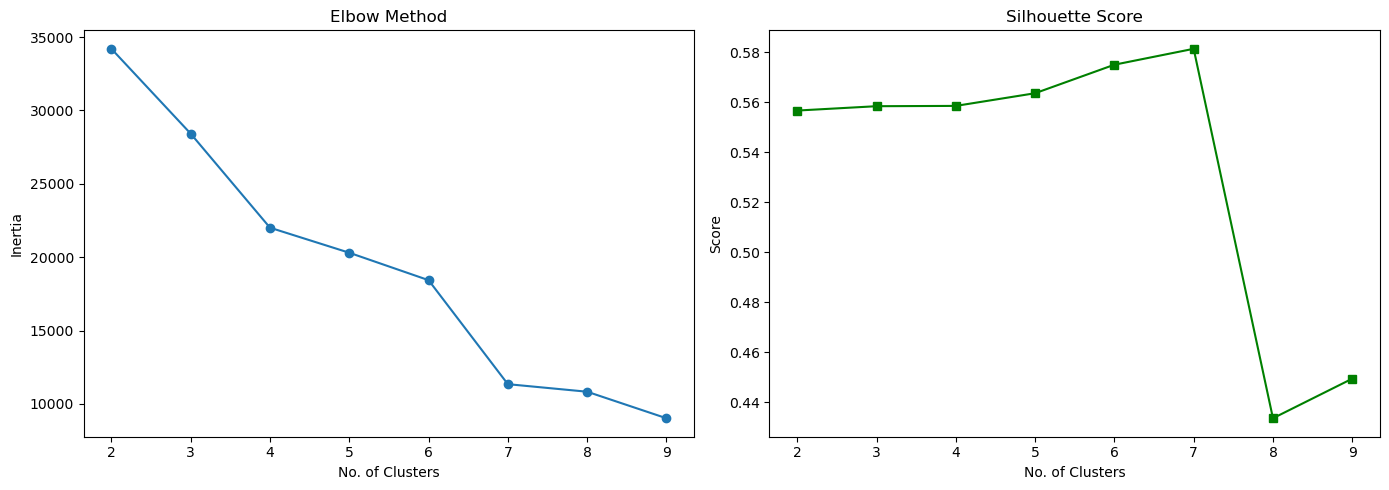

In [21]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

inertia = []
silhouette_scores = []
cluster_range = range(2, 10)

for k in cluster_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(cluster_range, inertia, marker='o')
plt.title('Elbow Method')
plt.xlabel('No. of Clusters')
plt.ylabel('Inertia')

plt.subplot(1, 2, 2)
plt.plot(cluster_range, silhouette_scores, marker='s', color='green')
plt.title('Silhouette Score')
plt.xlabel('No. of Clusters')
plt.ylabel('Score')

plt.tight_layout()
plt.show()


# Forecasting Vendor Performance ( with Prophet)

In [26]:
pip install prophet


Defaulting to user installation because normal site-packages is not writeableNote: you may need to restart the kernel to use updated packages.



####   Prepare the DataFrame

In [28]:
import pandas as pd

# Simulated monthly profit data for a vendor
df = pd.DataFrame({
    'ds': pd.date_range(start='2022-01-01', periods=24, freq='M'),
    'y': [52000, 53000, 49000, 47000, 50000, 52000,
          58000, 60000, 61000, 63000, 64000, 62000,
          65000, 68000, 70000, 69000, 67000, 66000,
          64000, 62000, 61000, 60000, 58000, 59000]
})


####  Train the Prophet Model

In [29]:
from prophet import Prophet

model = Prophet()
model.fit(df)


18:54:50 - cmdstanpy - INFO - Chain [1] start processing
18:54:52 - cmdstanpy - INFO - Chain [1] done processing


#### Forecast the Next 6 Months

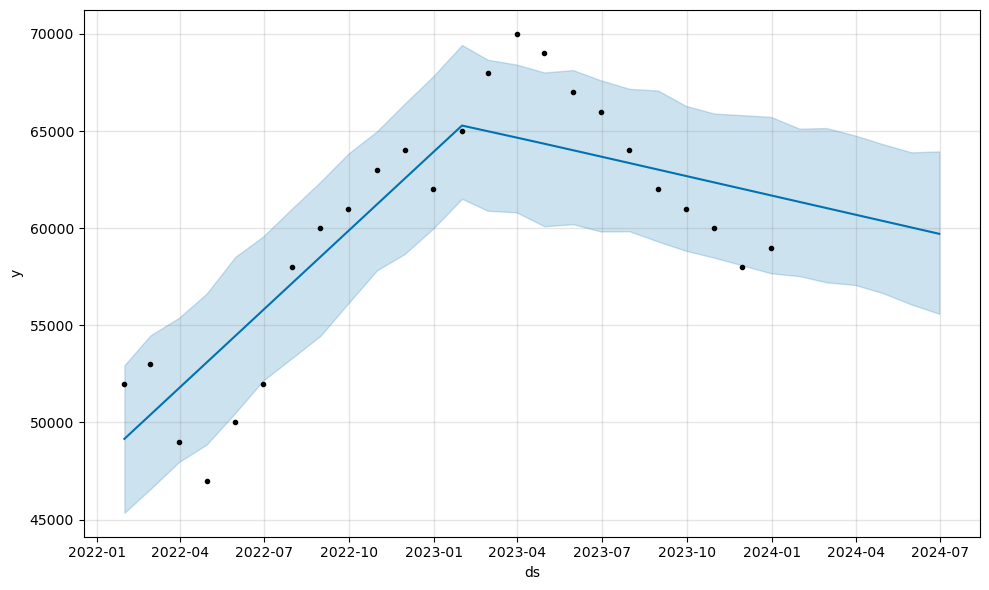

In [30]:
# Create a future DataFrame
future = model.make_future_dataframe(periods=6, freq='M')

# Predict
forecast = model.predict(future)

# Plot
fig = model.plot(forecast)


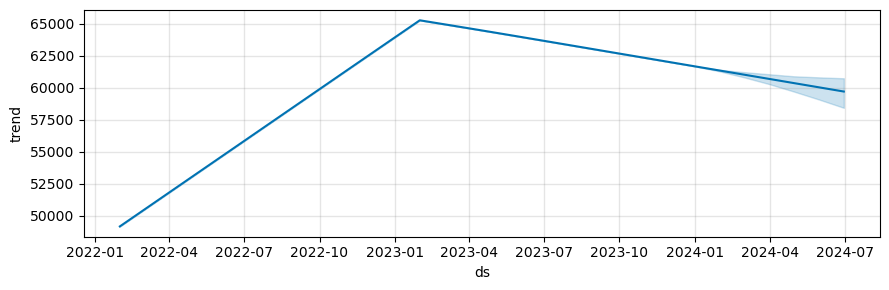

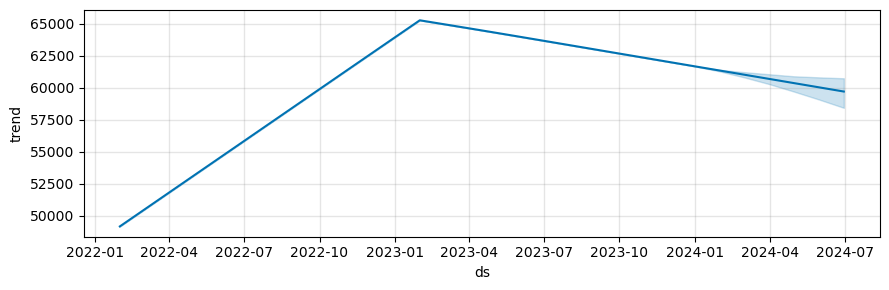

In [31]:
model.plot_components(forecast)
